Source of data

The dataset was acquired using web-scraping methods, extracting the passenger information from a publicly available website. After scraping, the data was saved locally as titanic.csv and subsequently cleaned and prepared for analysis.

[link source](https://calmcode.io/datasets/titanic?utm_source=chatgpt.com)


We downloaded the data with the below command line

wget https://calmcode.io/static/data/titanic.csv

**Cleaning & Examining**

We first loaded the titanic.csv file and examined:
The first few rows
The data types of each column
How many missing values each variable had
This helped understand which variables needed attention.

2. Removed duplicate rows
We checked for exact duplicate entries in the dataset.
If any duplicates were found, they were dropped to prevent the same passenger from being counted twice.

3. Handled missing values in the numeric variables
The variables age, fare, sibsp, and parch were selected as numeric features.
Some of them (especially age) contained missing values.
To clean them:
Missing numeric values were replaced using the median of each variable.
The median is a robust choice because it is less sensitive to outliers than the mean.

4. Cleaned and standardized categorical variables
For the categorical variables:
sex values were cleaned by converting everything to lowercase and stripping spaces
survived, pclass, and sex were converted to the categorical data type
This makes the dataset easier to work with and prevents mistakes in later modeling steps.

5. Selected 4 categorical and 4 numerical variables
From the full dataset, kept only the variables required:
Categorical:
survived
pclass
sex
name
Numeric:
age
fare
sibsp
parch


In [3]:
import pandas as pd

# 1) LOAD DATA (file name: titanic.csv)
titanic = pd.read_csv("titanic.csv")

print("=== First 5 rows ===")
print(titanic.head(), "\n")

print("=== Info ===")
print(titanic.info(), "\n")

print("=== Missing values per column ===")
print(titanic.isna().sum(), "\n")

# 2) BASIC CLEANING

# 2.1 Drop exact duplicate rows (if any)
before = len(titanic)
titanic = titanic.drop_duplicates()
after = len(titanic)
print(f"Dropped {before - after} duplicate rows.\n")

# 2.2 Handle missing numeric values (age, fare, sibsp, parch)
numeric_cols = ["age", "fare", "sibsp", "parch"]

for col in numeric_cols:
    if col in titanic.columns and titanic[col].isna().sum() > 0:
        median_val = titanic[col].median()
        titanic[col] = titanic[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val:.2f}")

print()

# 2.3 Clean categorical columns a bit
# We'll use these as categorical:
cat_cols = ["survived", "pclass", "sex", "name"]

# Only keep the ones that actually exist in your file
cat_cols = [c for c in cat_cols if c in titanic.columns]

# Strip whitespace & lowercase for 'sex' just in case
if "sex" in titanic.columns:
    titanic["sex"] = (
        titanic["sex"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Convert some columns to categorical dtype if present
if "survived" in titanic.columns:
    titanic["survived"] = titanic["survived"].astype("category")
if "pclass" in titanic.columns:
    titanic["pclass"] = titanic["pclass"].astype("category")
if "sex" in titanic.columns:
    titanic["sex"] = titanic["sex"].astype("category")

print("=== Categorical value counts ===")
if "survived" in titanic.columns:
    print("survived:\n", titanic["survived"].value_counts(), "\n")
if "pclass" in titanic.columns:
    print("pclass:\n", titanic["pclass"].value_counts(), "\n")
if "sex" in titanic.columns:
    print("sex:\n", titanic["sex"].value_counts(), "\n")

# 3) KEEP ONLY 4 NUMERIC + 4 CATEGORICAL VARIABLES

numeric_vars = [c for c in ["age", "fare", "sibsp", "parch"] if c in titanic.columns]
categorical_vars = [c for c in ["survived", "pclass", "sex", "name"] if c in titanic.columns]

cols_to_keep = categorical_vars + numeric_vars
titanic_subset = titanic[cols_to_keep].copy()

print("\n=== Subset columns ===")
print(titanic_subset.head(), "\n")
print("Columns kept:", cols_to_keep, "\n")

# 4) SAVE CLEANED DATASET
titanic_subset.to_csv("titanic_cleaned_subset.csv", index=False)
print("Saved cleaned dataset to 'titanic_cleaned_subset.csv'")


=== First 5 rows ===
   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age     fare  sibsp  parch  
0    male  22.0   7.2500      1      0  
1  female  38.0  71.2833      1      0  
2  female  26.0   7.9250      0      0  
3  female  35.0  53.1000      1      0  
4    male  35.0   8.0500      0      0   

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   name    

**Explanation of every variable**

Categorical Variables
1. survived
Indicates whether the passenger survived the Titanic disaster.
0 = did not survive
1 = survived
2. pclass
Passenger’s ticket class, which reflects socioeconomic status:
1 = First class (rich)
2 = Second class (middle)
3 = Third class (lower)
3. sex
The biological sex of the passenger:
male
female
4. name
The full name of the passenger.
This can also include titles (Mr., Mrs., Miss, Master, Dr.), which sometimes help in analysis.

Numeric Variables

5. age
The passenger’s age in years.
Contains a mix of children, adults, and elderly individuals.
(Some values were originally missing and were filled with the median.)

6. fare
The price the passenger paid for their ticket.
Higher fares generally indicate wealthier passengers.

7. sibsp
Number of siblings and spouses the passenger had on board.
For example:
1 means they had one sibling or spouse with them.

8. parch 
Number of parents and children the passenger had on board.
For example:
2 means they were traveling with two family members in this category.

Columns: ['survived', 'pclass', 'sex', 'name', 'age', 'fare', 'sibsp', 'parch']
   survived  pclass     sex  \
0         0       3    male   
1         1       1  female   
2         1       3  female   
3         1       1  female   
4         0       3    male   

                                                name   age     fare  sibsp  \
0                            Braund, Mr. Owen Harris  22.0   7.2500      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  71.2833      1   
2                             Heikkinen, Miss. Laina  26.0   7.9250      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  53.1000      1   
4                           Allen, Mr. William Henry  35.0   8.0500      0   

   parch  
0      0  
1      0  
2      0  
3      0  
4      0  


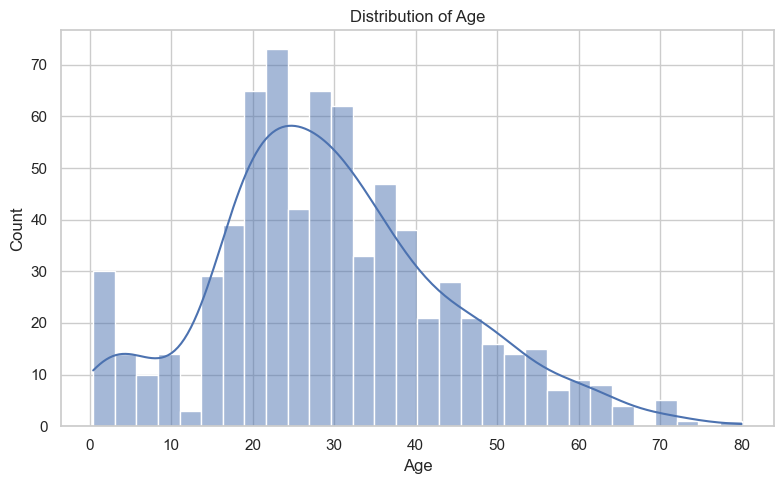

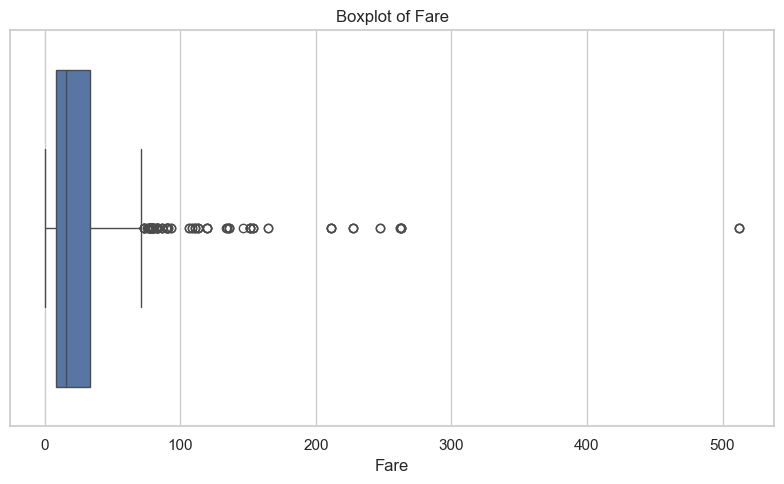

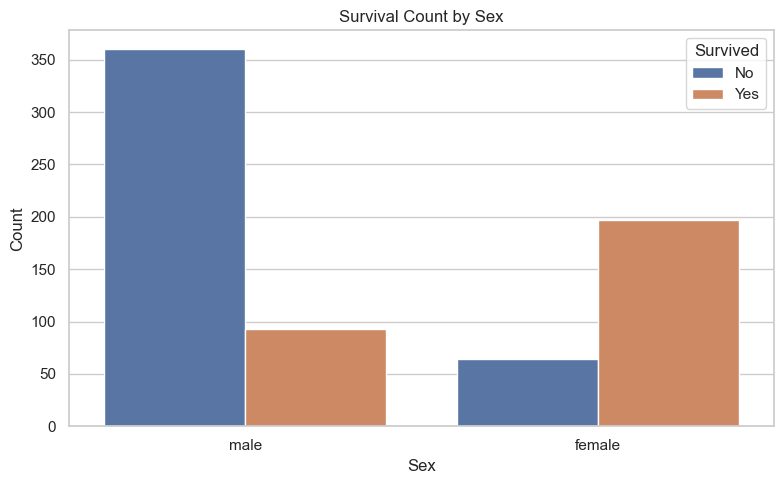

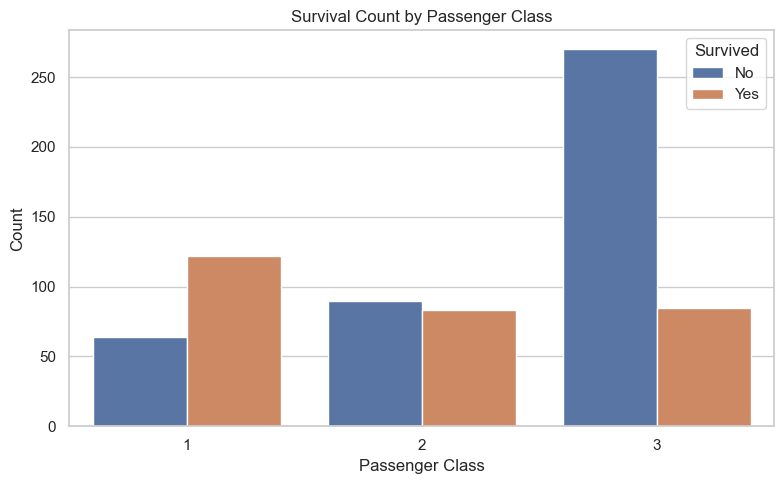

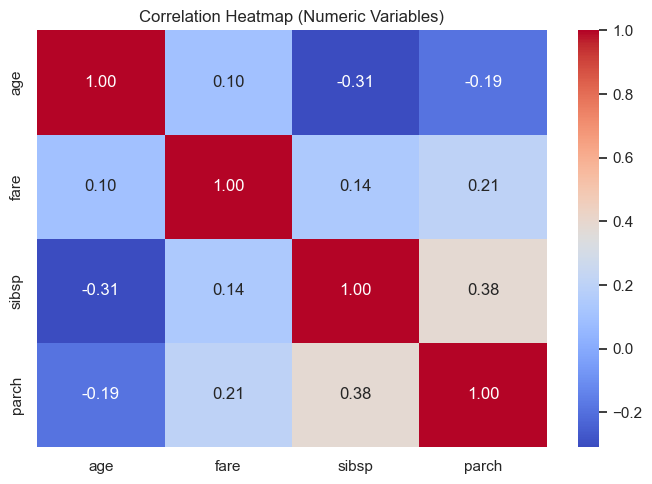

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
titanic = pd.read_csv("titanic_cleaned_subset.csv")

print("Columns:", titanic.columns.tolist())
print(titanic.head())

sns.set_theme(style="whitegrid")

# 1) Histogram – Age
plt.figure(figsize=(8, 5))
sns.histplot(titanic["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_age_hist.png")
plt.show()

# 2) Boxplot – Fare
plt.figure(figsize=(8, 5))
sns.boxplot(x=titanic["fare"])
plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.tight_layout()
plt.savefig("eda_fare_box.png")
plt.show()

# 3) Survival vs Sex (bar chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=titanic, x="sex", hue="survived")
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("eda_survival_sex.png")
plt.show()

# 4) Survival vs Pclass (bar chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=titanic, x="pclass", hue="survived")
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.tight_layout()
plt.savefig("eda_survival_pclass.png")
plt.show()

# 5) Correlation heatmap for numeric vars
plt.figure(figsize=(7, 5))
num_cols = ["age", "fare", "sibsp", "parch"]
corr = titanic[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.savefig("eda_corr_heatmap.png")
plt.show()
